In [70]:
import pandas as pd

units_lca = pd.read_csv('LCA_cal/lca_by_unit.csv')
units_lcoe = pd.read_csv('LCOE_cal/lcoe_by_unit.csv')

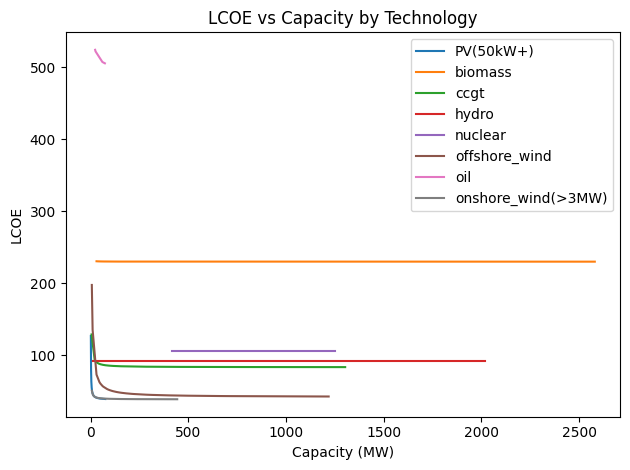

In [71]:
import matplotlib.pyplot as plt

def plot_lcoe_by_capacity(df, x_col='capacity_mw', y_col='lcoe_total', tech_col='tech',
                          title='LCOE vs Capacity by Technology'):

    df = df[[tech_col, x_col, y_col]].dropna().copy()
    df = df[pd.to_numeric(df[x_col], errors='coerce').notna() &
            pd.to_numeric(df[y_col], errors='coerce').notna()]
    df[x_col] = df[x_col].astype(float)
    df[y_col] = df[y_col].astype(float)

    plt.figure()
    for tech, g in df.groupby(tech_col):
        g_sorted = g.sort_values(by=x_col)
        plt.plot(g_sorted[x_col], g_sorted[y_col], label=str(tech))

    plt.xlabel('Capacity (MW)')
    plt.ylabel('LCOE')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# mask = units_lcoe['tech'].isin(['ccgt'])
# df_small = units_lcoe[mask & units_lcoe['capacity_mw'].between(0, 200)]
# plot_lcoe_by_capacity(df_small)
# units_lcoe = units_lcoe[units_lcoe['tech'] != 'oil']   
plot_lcoe_by_capacity(units_lcoe)

# plot_lcoe_by_capacity(units_lcoe)

